
# Lecture 8, Calibrating a hydrological model

The model of Lecture 7 has five parameters, and none of them can be measured in the
field: $S_{max}$, $\beta$, $k_{perc}$, $k_f$ and $k_s$ are *effective* quantities for
the whole catchment. We infer them by running the model with many parameter sets and
keeping the ones that make the simulated streamflow look most like the observed
streamflow. That inference is **calibration**.

Calibration raises four questions this lecture works through:

1. *"Look most like"* &mdash; measured how? (objective functions)
2. How do we know the calibrated model will work on data it was not fitted to?
   (split-sample testing)
3. If the method works perfectly on a problem where we know the answer, why does it
   only get part-way on real data? (an identical-twin test)
4. If several very different parameter sets fit almost equally well, which one is
   right? (equifinality)


In [1]:
import sys
if "google.colab" in sys.modules:
    %pip install -q numpy pandas matplotlib scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/chattooga_daily.csv", comment="#",
                 parse_dates=["date"], index_col="date")
P = df["prcp_mm"].to_numpy(float)
Ep = df["pet_mm"].to_numpy(float)
Qobs = df["q_mm"].to_numpy(float)


## The model, vectorised

This is the Lecture 7 model with one change: the parameters can be **arrays**, so a
whole ensemble of parameter sets is stepped through the loop at once. Running 3000
parameter sets then costs one pass over the record instead of 3000, which is what makes
Monte Carlo and population-based optimisers practical.


In [2]:
PARAM_NAMES = ["smax", "beta", "kperc", "kf", "ks"]

def simulate(theta, prcp=P, pet=Ep):
    """Lumped model of Lecture 7. theta: (n_sets, 5) or (5,). Returns (n_time,) or (n_time, n_sets)."""
    th = np.atleast_2d(np.asarray(theta, float))
    smax, beta, kperc, kf, ks = (th[:, i] for i in range(5))
    S = 0.5 * smax.copy()
    F1 = np.zeros_like(smax); F2 = np.zeros_like(smax); R = np.zeros_like(smax)
    q = np.empty((len(prcp), smax.size))
    for t in range(len(prcp)):
        p, ep = prcp[t], pet[t]
        s = np.clip(S / smax, 0.0, 1.0)
        runoff = p * s ** beta
        aet = ep * s * (2.0 - s)
        S = S + p - runoff - aet
        runoff = runoff + np.maximum(S - smax, 0.0); S = np.minimum(S, smax)
        aet = aet + np.minimum(S, 0.0);             S = np.maximum(S, 0.0)
        perc = kperc * S * s ** 3
        S = S - perc
        F1 = F1 + runoff; R = R + perc
        o1 = kf * F1; F1 = F1 - o1
        F2 = F2 + o1;  o2 = kf * F2; F2 = F2 - o2
        qs = ks * R;   R = R - qs
        q[t] = o2 + qs
    return q.squeeze()

BOUNDS = np.array([[50.0, 700.0],   # smax  [mm]
                   [0.5, 6.0],      # beta  [-]
                   [0.0, 0.4],      # kperc [1/day]
                   [0.05, 0.9],     # kf    [1/day]
                   [0.003, 0.15]])  # ks    [1/day]


## 1) Objective functions

An objective function turns the mismatch between two time series into one number. Four
are in common use in hydrology; each rewards a different kind of agreement.

**Nash&ndash;Sutcliffe efficiency (NSE)** compares the model against the mean of the
observations:

$$\text{NSE} = 1 - \frac{\sum (Q_{sim} - Q_{obs})^2}{\sum (Q_{obs} - \overline{Q_{obs}})^2}.$$

NSE $= 1$ is perfect, NSE $= 0$ means the model is no better than predicting the mean
flow every day, and NSE $< 0$ is worse than that. Because the errors are squared, NSE
is dominated by the largest flows &mdash; a good NSE means the flood peaks are right.

**Log-NSE** is NSE computed on $\ln(Q + \varepsilon)$. Taking logs compresses the
peaks and stretches the low flows, so log-NSE measures how well the model does in the
dry season.

**Kling&ndash;Gupta efficiency (KGE)** breaks the error into three parts &mdash;
correlation $r$, a variability ratio $\alpha = \sigma_{sim}/\sigma_{obs}$, and a bias
ratio $\beta = \mu_{sim}/\mu_{obs}$ &mdash; and combines them:

$$\text{KGE} = 1 - \sqrt{(r-1)^2 + (\alpha-1)^2 + (\beta-1)^2}.$$

**RMSE** is just the root-mean-square error, in mm day⁻¹ &mdash; interpretable, but it
grows with the size of the flows so it cannot be compared between catchments.


In [3]:
def nse(obs, sim):
    m = np.isfinite(obs) & np.isfinite(sim)
    o, s = obs[m], sim[m]
    return 1.0 - np.sum((s - o) ** 2) / np.sum((o - o.mean()) ** 2)

def lognse(obs, sim, eps=None):
    eps = eps if eps is not None else 0.01 * np.nanmean(obs)
    return nse(np.log(obs + eps), np.log(sim + eps))

def kge(obs, sim):
    m = np.isfinite(obs) & np.isfinite(sim)
    o, s = obs[m], sim[m]
    r = np.corrcoef(o, s)[0, 1]
    return 1.0 - np.sqrt((r - 1) ** 2 + (s.std() / o.std() - 1) ** 2
                         + (s.mean() / o.mean() - 1) ** 2)

def rmse(obs, sim):
    m = np.isfinite(obs) & np.isfinite(sim)
    return np.sqrt(np.mean((sim[m] - obs[m]) ** 2))


Score one simulation &mdash; the "first guess" parameters from Lecture 7 &mdash; with
all four metrics. They disagree, because they are measuring different things.


In [4]:
t = df.index
q1 = np.asarray(simulate([250.0, 2.5, 0.05, 0.40, 0.015]))
ev = t >= "1993-01-01"                             # drop the warm-up
print(f"  NSE    = {nse(Qobs[ev], q1[ev]):.3f}")
print(f"  logNSE = {lognse(Qobs[ev], q1[ev]):.3f}")
print(f"  KGE    = {kge(Qobs[ev], q1[ev]):.3f}")
print(f"  RMSE   = {rmse(Qobs[ev], q1[ev]):.3f} mm/d")


  NSE    = 0.638
  logNSE = 0.799
  KGE    = 0.735
  RMSE   = 1.573 mm/d


Why the disagreement? Plot the two error terms that NSE and log-NSE actually sum: the
squared error $(Q_{sim} - Q_{obs})^2$ and its logarithmic counterpart.


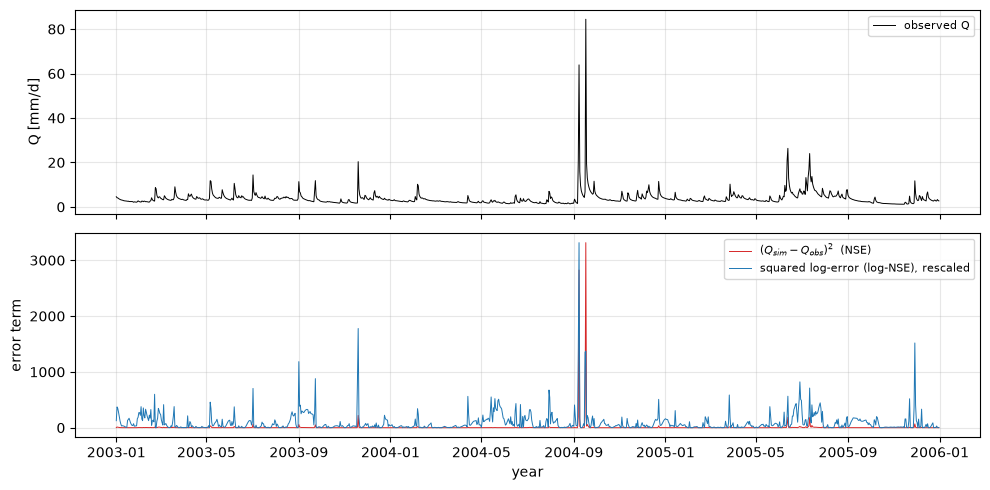

In [5]:
eps = 0.01 * np.nanmean(Qobs)
sq = (q1 - Qobs) ** 2
sqlog = (np.log(q1 + eps) - np.log(Qobs + eps)) ** 2

win = (t >= "2003-01-01") & (t < "2006-01-01")
fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
ax[0].plot(t[win], Qobs[win], color="black", lw=0.7, label="observed Q")
ax[0].set_ylabel("Q [mm/d]"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
ax[1].plot(t[win], sq[win], color="tab:red", lw=0.7, label="$(Q_{sim}-Q_{obs})^2$  (NSE)")
ax[1].plot(t[win], sqlog[win] * sq[win].max() / sqlog[win].max(), color="tab:blue",
           lw=0.7, label="squared log-error (log-NSE), rescaled")
ax[1].set_ylabel("error term"); ax[1].set_xlabel("year")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
fig.tight_layout()


The plain squared error is a spike train: it is essentially zero except during a
handful of flood days, so **NSE is a flood metric** &mdash; a model can have a good NSE
and still be useless in the dry season. The squared log-error is spread evenly across
wet and dry periods, so **log-NSE weights all flows** and rewards getting the
recessions and low flows right. **KGE** sits between the two and additionally penalises
the model for having the wrong mean or the wrong variability.

The objective function is a modelling *choice*: for a flood study, calibrate on NSE;
for a drought or water-supply study, on log-NSE or KGE; often on a weighted
combination. For the rest of this lecture we calibrate on **NSE**.


## 2) Split-sample testing

A model with five free parameters can be tuned to fit almost any single record. The
test that matters is whether it then works on a *different* period. So we divide the
25-year record into three:

- **warm-up** (1991&ndash;1993) &mdash; run but not scored, to forget the initial guess;
- **calibration** (1994&ndash;2007) &mdash; the parameters are chosen to maximise NSE here;
- **validation** (2008&ndash;2015) &mdash; never seen during calibration; the honest test.


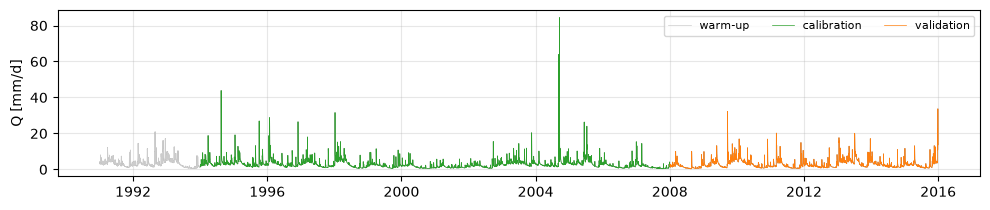

In [6]:
warmup = df.index < "1994-01-01"
cal = (df.index >= "1994-01-01") & (df.index < "2008-01-01")
val = df.index >= "2008-01-01"

fig, ax = plt.subplots(figsize=(10, 2.2))
ax.plot(t, Qobs, color="0.6", lw=0.5)
for m, c, lbl in [(warmup, "0.8", "warm-up"), (cal, "tab:green", "calibration"),
                  (val, "tab:orange", "validation")]:
    ax.plot(t[m], Qobs[m], color=c, lw=0.5, label=lbl)
ax.set_ylabel("Q [mm/d]"); ax.legend(ncol=3, fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout()

def score(theta, mask, metric=nse):
    return metric(Qobs[mask], np.asarray(simulate(theta))[mask])


## 3) An identical-twin test

Before calibrating a real catchment it is worth checking the machinery on a problem
where the answer is known. In an **identical-twin** (or *synthetic*) experiment we
*generate* a streamflow series by running the model with a chosen "true" parameter set,
then hand that series to the calibration as if it were an observation and see whether
the true parameters come back.

We use a global optimiser, `differential_evolution`: it does not get stuck in local
optima, needs no gradients, and SciPy can evaluate a whole population in one vectorised
call. Each calibration below takes roughly half a minute.


In [7]:
from scipy.optimize import differential_evolution

def calibrate(target, mask=cal, maxiter=40, popsize=12):
    """Return the parameter set that maximises NSE against `target` over `mask`."""
    o = target[mask][:, None]
    denom = np.nansum((o - np.nanmean(o)) ** 2)
    def cost(x):                                  # x: (5, popsize)
        s = simulate(x.T)[mask]
        return np.nansum((s - o) ** 2, 0) / denom
    r = differential_evolution(cost, BOUNDS, vectorized=True, seed=1,
                               maxiter=maxiter, popsize=popsize, tol=1e-6)
    return r.x

theta_true = np.array([220.0, 3.0, 0.08, 0.45, 0.012])
Q_true = np.asarray(simulate(theta_true))         # the synthetic "observations"

# (a) calibrate against the clean synthetic series
theta_clean = calibrate(Q_true)

# (b) calibrate against the same series with 15% random noise added
noise = np.random.default_rng(42).standard_normal(len(Q_true))
Q_noisy = np.maximum(Q_true * (1.0 + 0.15 * noise), 0.0)
theta_noisy = calibrate(Q_noisy)

tbl = pd.DataFrame({"true": theta_true,
                    "recovered, clean": theta_clean,
                    "recovered, 15% noise": theta_noisy}, index=PARAM_NAMES)
print(tbl.round(3).to_string())
print(f"\nNSE of the recovered model against the TRUE series:")
print(f"  from clean data : {nse(Q_true[cal], np.asarray(simulate(theta_clean))[cal]):.4f}")
print(f"  from noisy data : {nse(Q_true[cal], np.asarray(simulate(theta_noisy))[cal]):.4f}")
print(f"NSE of the noisy-data fit against the NOISY series it was fitted to: "
      f"{nse(Q_noisy[cal], np.asarray(simulate(theta_noisy))[cal]):.3f}")


D:\New folder\OneDrive\Teaching\CE524\git\hydroclimatology\.venv\Lib\site-packages\scipy\optimize\_differentialevolution.py:518: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


          true  recovered, clean  recovered, 15% noise
smax   220.000           220.564               222.141
beta     3.000             2.986                 3.036
kperc    0.080             0.081                 0.077
kf       0.450             0.451                 0.447
ks       0.012             0.012                 0.012

NSE of the recovered model against the TRUE series:
  from clean data : 1.0000


  from noisy data : 0.9999
NSE of the noisy-data fit against the NOISY series it was fitted to: 0.934


With **clean** synthetic data the optimiser recovers every parameter to three or four
significant figures and the fit is perfect (NSE $= 1.0000$). With **15% noise** it
still recovers the parameters to within a percent or two, and the recovered model is
almost identical to the truth &mdash; but it can no longer fit the *noisy* series past
NSE $\approx 0.93$, because a smooth model cannot reproduce random noise. The noise
sets a ceiling on the achievable score.

So the calibration method works. When the same method reaches only NSE $\approx 0.65$
on the real Chattooga (Sections 6&ndash;7), that is **not** the optimiser failing
&mdash; it is telling us something about the model and the data, which we come back to
after calibrating for real.



## 4) The real catchment: manual calibration first

Now the real problem. Before automating anything, turn the knobs by hand for a few
minutes &mdash; it builds the intuition that tells you whether an automatic result is
sensible.


In [8]:
trials = {
    "first guess":  [250.0, 2.5, 0.05, 0.40, 0.015],
    "flashier":     [150.0, 3.0, 0.04, 0.55, 0.012],
    "more storage": [400.0, 2.0, 0.08, 0.35, 0.010],
}
rows = []
for name, th in trials.items():
    rows.append([name, score(th, cal), score(th, val)])
print(pd.DataFrame(rows, columns=["parameter set", "NSE cal", "NSE val"]).round(3).to_string(index=False))


parameter set  NSE cal  NSE val
  first guess    0.587    0.718
     flashier    0.408    0.371
 more storage    0.543    0.697


Hand-tuning gets us into the right region but stalls: it is hard to juggle five
parameters at once, and easy to fool yourself. Automatic search does the juggling
systematically.


## 5) Monte Carlo (random search)

The simplest automatic method: draw thousands of parameter sets at random from within
the bounds, run them all, and look at the results. It is not efficient, but it is
robust, trivially parallel, and &mdash; crucially &mdash; it shows the *whole* response
surface, not just the optimum.


best of 6000 random sets:  NSE cal = 0.625
  smax=215, beta=3.61, kperc=0.13, kf=0.531, ks=0.0102


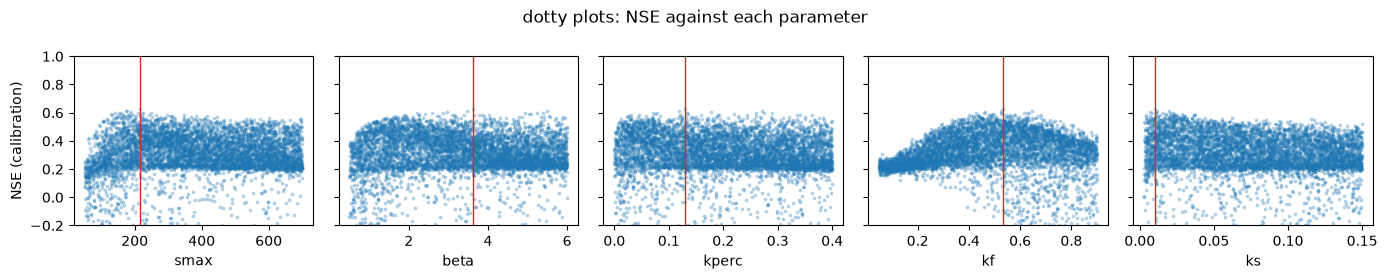

In [9]:
rng = np.random.default_rng(0)
N = 6000
X = BOUNDS[:, 0] + rng.random((N, 5)) * (BOUNDS[:, 1] - BOUNDS[:, 0])

Qens = simulate(X)                                   # (n_time, N), one pass
o = Qobs[cal][:, None]; s = Qens[cal]
mc_nse = 1.0 - np.nansum((s - o) ** 2, axis=0) / np.nansum((o - np.nanmean(o)) ** 2, axis=0)

best = int(np.argmax(mc_nse))
print(f"best of {N} random sets:  NSE cal = {mc_nse[best]:.3f}")
print("  " + ", ".join(f"{n}={v:.3g}" for n, v in zip(PARAM_NAMES, X[best])))

fig, axes = plt.subplots(1, 5, figsize=(14, 2.8), sharey=True)
for j, (ax, name) in enumerate(zip(axes, PARAM_NAMES)):
    ax.scatter(X[:, j], mc_nse, s=3, alpha=0.25, color="tab:blue")
    ax.axvline(X[best, j], color="tab:red", lw=1)
    ax.set_xlabel(name); ax.set_ylim(-0.2, 1.0)
axes[0].set_ylabel("NSE (calibration)")
fig.suptitle("dotty plots: NSE against each parameter")
fig.tight_layout()


These **dotty plots** are diagnostic. Where the top edge of the cloud forms a clear
peak &mdash; here for the two recession coefficients $k_s$ and $k_f$ &mdash; the data
*identify* that parameter: only a narrow range gives high NSE. Where the top edge is
flat &mdash; here $\beta$ and $k_{perc}$, which mostly rearrange water between stores
without changing the outflow much &mdash; the parameter is **poorly identified**: many
values work equally well and the calibration cannot pin it down. $S_{max}$ is
in between.



## 6) Automatic optimisation

Random search wastes most of its runs far from the optimum. The `differential_evolution`
optimiser introduced in the twin test spends its budget where the score is improving;
applied to the real catchment it converges in the same half-minute.


In [10]:

theta_cal = calibrate(Qobs)                        # same helper as the twin test

print("calibrated parameters:")
for name, v in zip(PARAM_NAMES, theta_cal):
    print(f"  {name:6s} = {v:.4g}")
print(f"\nNSE cal = {score(theta_cal, cal):.3f}   NSE val = {score(theta_cal, val):.3f}")


D:\New folder\OneDrive\Teaching\CE524\git\hydroclimatology\.venv\Lib\site-packages\scipy\optimize\_differentialevolution.py:518: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


calibrated parameters:
  smax   = 181.8
  beta   = 3.391
  kperc  = 0.1301
  kf     = 0.5323
  ks     = 0.01234



NSE cal = 0.647   NSE val = 0.701


## 7) Validation

The number that matters is the validation NSE. If it is close to the calibration NSE,
the model **generalises**; if it collapses, the calibration has fitted noise or a
period-specific quirk.


        calibration (1994-2007)  validation (2008-2015)
NSE                       0.647                   0.701
logNSE                    0.767                   0.753
KGE                       0.692                   0.811
RMSE                      1.597                   1.376


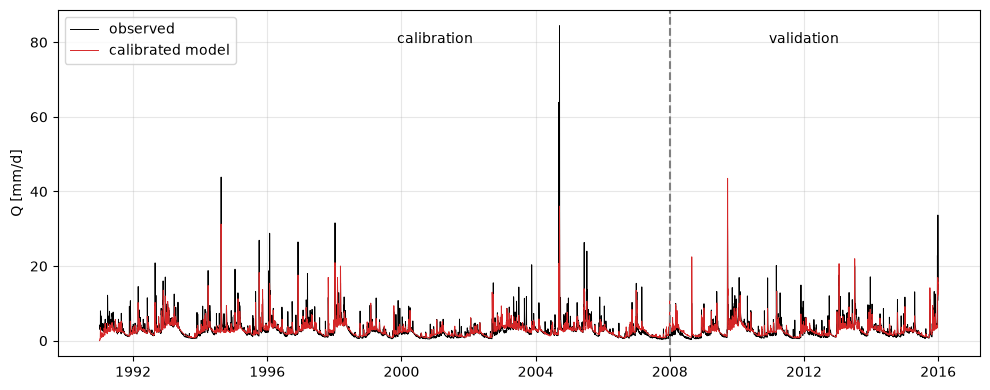

In [11]:
qcal = np.asarray(simulate(theta_cal))
metrics = pd.DataFrame({
    "calibration (1994-2007)": [nse(Qobs[cal], qcal[cal]), lognse(Qobs[cal], qcal[cal]),
                                kge(Qobs[cal], qcal[cal]), rmse(Qobs[cal], qcal[cal])],
    "validation (2008-2015)":  [nse(Qobs[val], qcal[val]), lognse(Qobs[val], qcal[val]),
                                kge(Qobs[val], qcal[val]), rmse(Qobs[val], qcal[val])],
}, index=["NSE", "logNSE", "KGE", "RMSE"]).round(3)
print(metrics.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, Qobs, color="black", lw=0.7, label="observed")
ax.plot(t, qcal, color="tab:red", lw=0.7, label="calibrated model")
ax.axvline(pd.Timestamp("2008-01-01"), color="0.5", ls="--")
ax.text(pd.Timestamp("2001"), ax.get_ylim()[1] * 0.9, "calibration", ha="center")
ax.text(pd.Timestamp("2012"), ax.get_ylim()[1] * 0.9, "validation", ha="center")
ax.set_ylabel("Q [mm/d]"); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()



The validation score here is a little *higher* than the calibration score &mdash; not
unusual, it just means the validation years happen to be hydrologically easier (fewer
extreme events). What we do not see is a collapse, so the calibrated parameters are
usable.

Now put the two experiments side by side. The identical-twin test reached NSE
$= 1.0000$; the real Chattooga tops out near $0.65$&ndash;$0.70$. That gap is **not**
calibration error &mdash; the method recovers known parameters exactly. It is the sum
of three things calibration cannot fix:

- **Structural error.** A five-parameter bucket is not the Chattooga. Real catchments
  route water through hillslopes, riparian zones and fractured rock that no lumped
  model resolves. Models like GR4J or HBV close part of the gap with a routing delay
  and more careful soil accounting, but a structural error always remains.
- **Input error.** The model is forced with grid-interpolated Daymet rainfall, not the
  rain that actually fell on the catchment; a missed convective storm is a missed peak
  no matter how the parameters are set.
- **Measurement error.** The gauge record itself comes from a stage&ndash;discharge
  rating curve that is extrapolated at the highest flows &mdash; exactly where the
  squared-error metrics care most.

Calibration finds the best parameters *given* the model and the data. It cannot make
the model the catchment.


## 8) Equifinality

Go back to the Monte Carlo ensemble and keep every run within 0.03 NSE of the best.
These are all "good" models. Their **hydrographs** are nearly indistinguishable &mdash;
but their **parameters** are not.


30 of 6000 random sets are within 0.05 NSE of the best

parameter ranges among the 'good' sets:
  smax        130 to      381   ( 39% of the allowed range)
  beta       1.66 to     5.54   ( 71% of the allowed range)
  kperc    0.0244 to    0.363   ( 85% of the allowed range)
  kf          0.4 to    0.682   ( 33% of the allowed range)
  ks      0.00447 to   0.0372   ( 22% of the allowed range)


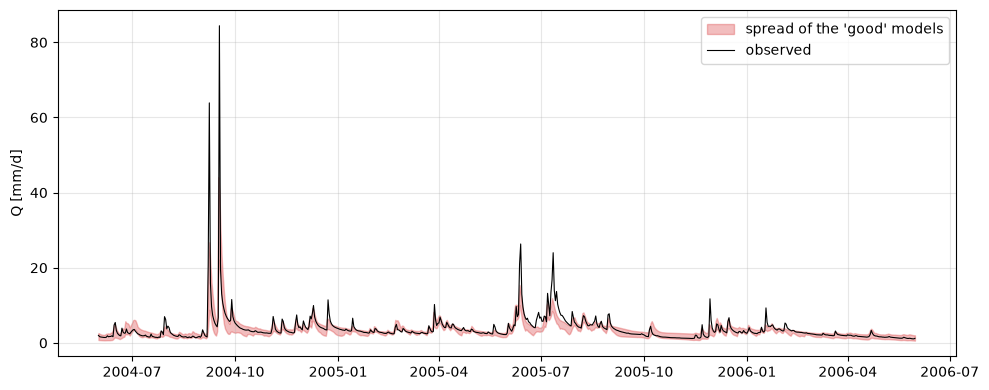

In [12]:
good = mc_nse > (mc_nse[best] - 0.05)
print(f"{good.sum()} of {N} random sets are within 0.05 NSE of the best\n")

print("parameter ranges among the 'good' sets:")
for j, name in enumerate(PARAM_NAMES):
    lo, hi = X[good, j].min(), X[good, j].max()
    frac = (hi - lo) / (BOUNDS[j, 1] - BOUNDS[j, 0])
    print(f"  {name:6s} {lo:8.3g} to {hi:8.3g}   ({frac*100:3.0f}% of the allowed range)")

win = (t >= "2004-06-01") & (t < "2006-06-01")
env = Qens[:, good][win]
fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(t[win], env.min(1), env.max(1), color="tab:red", alpha=0.3,
                label="spread of the 'good' models")
ax.plot(t[win], Qobs[win], color="black", lw=0.8, label="observed")
ax.set_ylabel("Q [mm/d]"); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()


$\beta$ and $k_{perc}$ range over most of their allowed span with almost no cost in
NSE, and $S_{max}$ is not much better &mdash; the streamflow at the outlet simply does
not contain enough information to determine them. Only $k_f$ and $k_s$ are tightly
constrained. This is **equifinality**: many parameter sets, and in principle many model
structures, reproduce the observations equally well.

The practical consequences:

- A single "optimal" parameter set is a convenient fiction. The honest product of
  calibration is an *ensemble* and the streamflow spread it implies.
- Calibrated parameters should not be read as physical properties of the catchment.
- Adding more parameters to chase a slightly higher NSE usually just adds more
  equifinality. Prefer the simplest structure that captures the behaviour you need.


## 9) Exercises

```{admonition} Exercise 1 &mdash; calibrate on a different objective
:class: tip
Re-run the optimiser with log-NSE, and then with KGE, as the objective. How different
are the calibrated parameters and the hydrographs? Which objective gives the best
*validation* NSE, and why is that not a contradiction?
```

```{admonition} Exercise 2 &mdash; how much data do you need?
:class: tip
Calibrate using only 2 years of the calibration period, then 5, then all 14. Plot the
validation NSE against calibration-record length. Where does it level off?
```

```{admonition} Exercise 3 &mdash; a GLUE-style uncertainty band
:class: tip
Weight each "good" Monte Carlo run by its NSE and use the weights to compute 5th and
95th percentile streamflow for each day of the validation period. What fraction of the
observed values fall inside the band? (This is the essence of the GLUE method.)
```


## Sources

**Data.** As Lecture 7: USGS streamflow (public domain), Daymet v4 forcing (ORNL DAAC,
public domain), Oudin (2005) PET, CAMELS catchment.

**Tools.** The calibration here is built from `numpy` and `scipy` for teaching. In
practice, [SPOTPY](https://spotpy.readthedocs.io/) (Houska et al.) provides a wide
range of optimisers and formal uncertainty methods (GLUE, DREAM), and
[LuMod](https://gitlab.com/Zaul_AE/lumod) bundles calibrated model structures with a
Monte Carlo interface.
